# For Marker | You can start marking near the bottom downwards

# Look For : "Video Frame Tracking - (Optical Flow) Pipeline - Final Version"


--------

### OLD Version!!! Video Frame Tracking - (Optical Flow) Pipeline - First Version
- Shows my initial foundational references, guides, and thought processes

In [ ]:
# Setup | Utilized for "Initial" & "Full" Version

# Essential Libraries
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Define | Data Directory
image_dir = "C:/Users/Zed/Desktop/AIML331/Assignment_2/AIML331_A2_Data/data/"
output_dir = "C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results"

In [24]:
# Image Preparation -> Analysis

# Inital View | Original Image State
img1 = cv2.imread(image_dir + 'frame_0.jpg') 
img2 = cv2.imread(image_dir + 'frame_1.jpg') 
h, w, = img1.shape[:2]

# Color conversion | BGR -> RGB (Correct Color Display)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


In [25]:
# Step 1 | Grid of points creation | Dense sampling

step_size = 35      # Adjust -> Based on desired resolution (FLow estimation) | Smaller Value (More steps / arrows), vice versa.
h, w = img1.shape
grid_x, grid_y = np.meshgrid(np.arange(0, w, step_size), np.arange(0, h, step_size))
points = np.vstack((grid_x.ravel(), grid_y.ravel())).T

# Step 2: Calculate | Opitcal flow -> each point | via lucas-Kanade
lk_params = dict(winSize=(15, 15), maxLevel=1)

flow_points = []
for pt in points:
    x, y = pt

    # Define | Small window around the current point + flow calculation
    flow_point = cv2.calcOpticalFlowPyrLK(img1, img2, np.array([[x, y]], dtype=np.float32), None, **lk_params)
    if flow_point[0] is not None:
        flow_points.append((pt, flow_point[0][0]))

# Convert ( List (flow points) -> numpy arrays )
flow_points = np.array(flow_points)
print(flow_points)

[[[ 0.00000000e+00  0.00000000e+00]
  [-8.39362717e+00  2.78666077e+01]]

 [[ 3.50000000e+01  0.00000000e+00]
  [ 1.65180492e+01  4.44776058e-01]]

 [[ 7.00000000e+01  0.00000000e+00]
  [ 9.85009995e+01  4.88252163e+00]]

 ...

 [[ 1.82000000e+03  1.05000000e+03]
  [ 1.79846289e+03  1.05027686e+03]]

 [[ 1.85500000e+03  1.05000000e+03]
  [ 1.83552612e+03  1.05051343e+03]]

 [[ 1.89000000e+03  1.05000000e+03]
  [ 1.87078442e+03  1.05047058e+03]]]


(-0.5, 1919.5, 1079.5, -0.5)

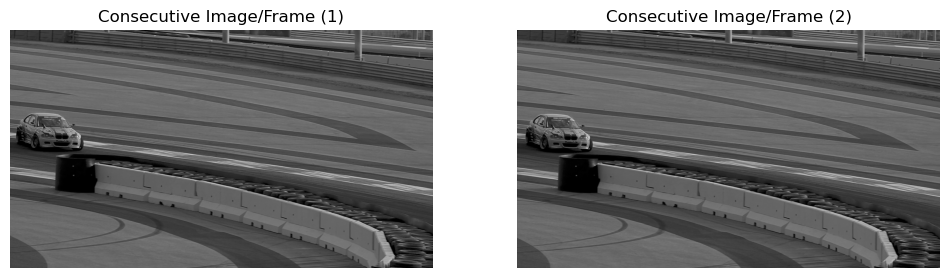

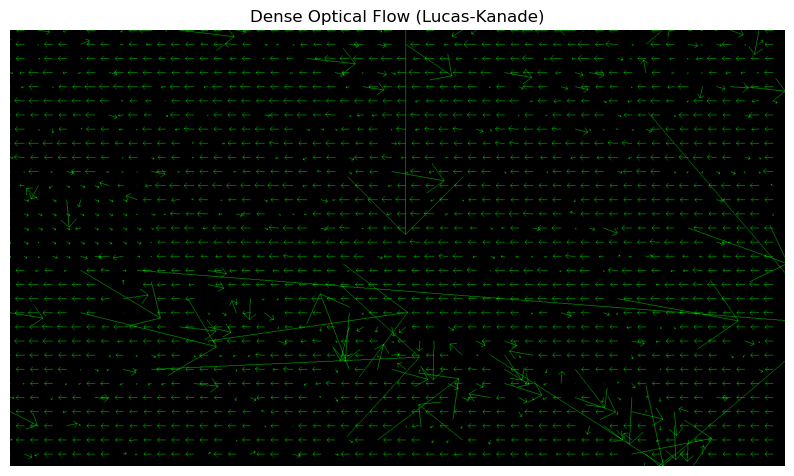

In [26]:
# Step 3 | Flow Visualization

# Create -> Image | Helps visualize the flow
flow_img = np.zeros_like(cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR))

# Draw -> Arrows (Represents flow)
for (x1, y1), (x2, y2) in flow_points:
    cv2.arrowedLine(flow_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 1,tipLength=0.4)


# Step 4 | Display Result
flow_img_rgb = cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Consecutive Image/Frame (1)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Consecutive Image/Frame (2)")
plt.axis("off")

plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(flow_img_rgb, cv2.COLOR_BGR2RGB))
plt.title("Dense Optical Flow (Lucas-Kanade)")
plt.axis("off")


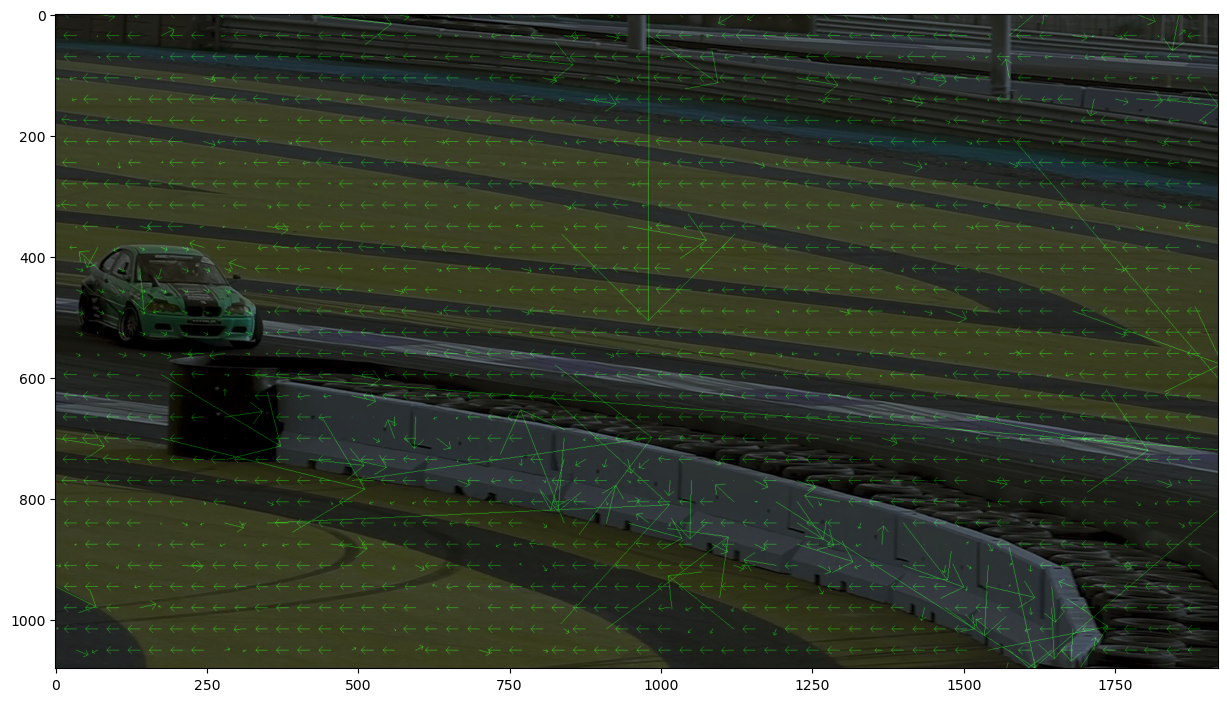

In [27]:
# Step 5 | Overlay Dense Optical Flow image on top of Consecutive Image/Frame 2)

img2_copy = cv2.imread(image_dir + 'frame_1.jpg') 

overlay = cv2.addWeighted(img2_copy, 0.5, flow_img_rgb, 0.5, 0)

plt.figure(figsize=(15,9))
plt.imshow(overlay)

### References 1

- w4_lec01_Local%20Features_Edge_CornerDetection_Harris.pdf
- w4_lec02_Local%20Feature_DoG%20and%20SIFT.pdf

- w5_lec02_Motion.pdf
- w5_Tutorial.pdf

------------

### Video Frame Tracking - (Optical Flow) Pipeline - Final Version

In [28]:
# Pseudo code / Framework | Taught by Ratanak R 

# Function
#   def (root dir, output dir, step size):

    # initial img
    # final img

    # Processing loop
        # for i in range (inital frame, end frame)
            # j = i + 1

            # load img1
            # Load img2

            # Optical flow calculation

            # Condition Check | If 5th frame save to directory
                # output path = os.path.join (outputdir , frame path)
                # dv2.imwrite (output path, image)
                # print path that was saved 

    # Function Finished


In [29]:
def optical_flow_calculation(root_dir, img1, img2, img2_path, step_size):

    # Section 1 | Calculate | Opitcal flow -> each point | via lucas-Kanade
    h, w = img1.shape
    
    grid_x, grid_y = np.meshgrid(np.arange(0, w, step_size), np.arange(0, h, step_size))
    points = np.vstack((grid_x.ravel(), grid_y.ravel())).T
   
    lk_params = dict(winSize=(15, 15), maxLevel=1)

    flow_points = []
    for pt in points:
        x, y = pt

        # Define | Small window around the current point + flow calculation
        flow_point = cv2.calcOpticalFlowPyrLK(img1, img2, np.array([[x, y]], dtype=np.float32), None, **lk_params)
        if flow_point[0] is not None:
            flow_points.append((pt, flow_point[0][0]))

    # Convert ( List (flow points) -> numpy arrays )
    flow_points = np.array(flow_points)
    #print(flow_points)

    # Section 2 | Flow Visualization ---------------------------------------------------------------------
    

    # Create -> Image | Helps visualize the flow
    flow_img = np.zeros_like(cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR))
    #flow_img = img1.copy() 

    # Draw -> Arrows (Represents flow)
    for (x1, y1), (x2, y2) in flow_points:
        cv2.arrowedLine(flow_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 1,tipLength=0.4)

    # Convert img to rgb
    flow_img_rgb = cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB)
    
    # Overlay Optical Flow image on rgb car image (1st image of the pair)
    img2_copy = cv2.imread(root_dir + img2_path) 

    flow_img_overlay = cv2.addWeighted(img2_copy, 0.5, flow_img_rgb, 0.5, 0)

    return flow_img_overlay

In [30]:
# Display Result

def display_result(flow_img_rgb):
    flow_img_rgb = cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Consecutive Image/Frame (1)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    plt.title("Consecutive Image/Frame (2)")
    plt.axis("off")

    plt.figure(figsize=(10,7))
    plt.imshow(cv2.cvtColor(flow_img_rgb, cv2.COLOR_BGR2RGB))
    plt.title("Dense Optical Flow (Lucas-Kanade)")
    plt.axis("off")

In [31]:
# Overlay Dense Optical Flow image on top of Consecutive Image/Frame 2)

def overlay_dense_oflow_img():
    img2_copy = cv2.imread(image_dir + 'frame_1.jpg') 

    overlay = cv2.addWeighted(img2_copy, 0.5, flow_img_rgb, 0.5, 0)

    plt.figure(figsize=(15,9))
    plt.imshow(overlay)

In [ ]:
def optical_flow_pipeline(root_dir, step_size, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    initial_img = 0
    final_img = 69

    # Processing Loop | Optical Calculations | Saving optical flow results of every 5th img
    for a in range(initial_img, final_img):
            b = a + 1
            
            ##### Image Preparation -> Analysis
            img1_path = f"frame_{a}.jpg"
            img2_path = f"frame_{b}.jpg"
            img1 = cv2.imread(root_dir + img1_path) 
            img2 = cv2.imread(root_dir + img2_path)
            
            #img1 = cv2.imread(root_dir + f"frame_{a}.jpg") 
            #img2 = cv2.imread(root_dir + f"frame_{b}.jpg")


            # Color conversion | BGR -> RGB (Correct Color Display)
            img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
            img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

            flow_img_overlay = optical_flow_calculation(root_dir, img1, img2, img2_path, step_size)
            """ 
                Section 1: Grid of points creation | Dense sampling
                Section 2: Flow Calculation + Visualization
                Section 3: Display result
                Section 4: Overlay Dense Optical Flow -> Image 
            """
            
            
            # Store every 5th optical flow image result
            if a % 5 ==0:
                output_path = os.path.join(output_dir, f"OpticalFlowResult_{a}_{b}.jpg")
                cv2.imwrite(output_path, flow_img_overlay)
                print(f"Succesfully saved: {output_path}")

    print("Pipeline operation has finished!")


In [34]:
optical_flow_pipeline(image_dir, 35, output_dir)

Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_0_1.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_5_6.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_10_11.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_15_16.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_20_21.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_25_26.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_30_31.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_35_36.jpg
Succesfully saved: C:/Users/Zed/Desktop/AIML331/Assignment_2/OpticalFlow_Results\OpticalFlowResult_40_41.jpg
Succesfully saved: C:/U

### References 2
- Functions: Arguments, 
    - W3 Schools. (2019). Python Functions. W3schools.com. https://www.w3schools.com/python/python_functions.asp
- For Loops
    - W3Schools. (n.d.). Python For Loops. W3schools.com. https://www.w3schools.com/python/python_for_loops.asp
- Format Strings
    - Python - Format Strings. (n.d.). Www.w3schools.com. https://www.w3schools.com/python/python_strings_format.asp

- Optical Flow Pipeline
    -  Pseudo code / Framework | Taught by Ratanak R 
   

‌